# Variational quantum time-propagation for Burgers

Amplitude-encodes the field into a parametrized circuit and steps forward in time via natural-gradient
descent, instead of Carleman linearization + QSVT (`carleman_qsvt/`). Each timestep minimizes
`||amp*psi(theta) - target_u||^2` against the forward-Euler target, using the McLachlan variational
principle (McLachlan, *Mol. Phys.* **8**, 39 (1964); Li & Benjamin, *Phys. Rev. X* **7**, 021050 (2017);
Yuan et al., *Quantum* **3**, 191 (2019)) combined with the parameter-shift rule (Mitarai et al.,
*Phys. Rev. A* **98**, 032309 (2018)) and a compute-uncompute overlap circuit for the nonlinear term.
Every circuit needs only a single generator insertion or a compute-uncompute pair, not a full-ansatz
controlled doubling -- see `pde_core.py`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

from discretization import periodic_D2, construct_F2_periodic_skew
import pde_core as pc
from plot_style import set_style, COLORS
set_style()

## Problem setup

n=3 (N=8), nu=0.01, u0=sin(2*pi*x) (unnormalized -- Burgers' nonlinear term is quadratic
while diffusion is linear, so the absolute amplitude of u0 changes the physics, not just
its shape; amp0=||u0|| is tracked separately from the normalized encoded state). Ansatz
depth reps=n (matching the expressivity a discrete-target fit needs).

In [2]:
n = 3
N = 2 ** n
x = np.linspace(0, 1, N, endpoint=False)
dx = x[1] - x[0]
nu = 0.01
dt = 0.1
n_steps = 3

u0 = np.sin(2 * np.pi * x)
amp0 = np.linalg.norm(u0)
u0n = u0 / amp0

ansatz = pc.build_ansatz_template(n)
P = ansatz.num_parameters
print(f"P = {P} ansatz parameters")

shift_fwd = pc.shift_power(n, 1, inverse=True)
shift_bwd = pc.shift_power(n, 1, inverse=False)
S1 = np.real(Operator(shift_fwd).data)
S1inv = np.real(Operator(shift_bwd).data)
identity_qc = QuantumCircuit(n)

# diffusion F1 = nu*(S + S^-1 - 2I)/dx^2
lin_terms = [
    ("S1", shift_fwd, S1, nu / dx**2),
    ("S1inv", shift_bwd, S1inv, nu / dx**2),
    ("id2", identity_qc, np.eye(N), -2 * nu / dx**2),
]

F1 = nu * periodic_D2(N, dx)
F2 = 1 / dx * construct_F2_periodic_skew(N)  # skew-symmetric: u^T F2(u kron u) = 0 identically


def classical_rhs(u):
    return F1 @ u + F2 @ np.kron(u, u)

P = 12 ansatz parameters


## Encoding the initial state

In [3]:
def init_loading(theta, target):
    return np.sum((pc.psi_of(ansatz, theta) - target) ** 2)


rng = np.random.default_rng(1)
best = None
for trial in range(10):
    guess = rng.random(P) * 2 * np.pi
    res = sp.optimize.minimize(init_loading, guess, args=(u0n,), method="BFGS")
    if best is None or res.fun < best.fun:
        best = res
theta = best.x
amp = amp0
print(f"encoding fit residual: {best.fun:.2e}")

encoding fit residual: 5.12e-12


## Time-propagation

In [4]:
classical_states = [u0.copy()]
quantum_states = [amp * pc.psi_of(ansatz, theta)]
theta_history = [theta.copy()]
amp_history = [amp]
u_classical = u0.copy()

for step in range(n_steps):
    u_classical = u_classical + dt * classical_rhs(u_classical)
    theta, amp = pc.natural_gradient_timestep(ansatz, theta, amp, dt, lin_terms, shift_fwd, shift_bwd, n_iter=150)
    u_quantum = amp * pc.psi_of(ansatz, theta)
    rel_err = np.linalg.norm(u_quantum - u_classical) / np.linalg.norm(u_classical)
    print(f"step {step + 1}/{n_steps}: rel. L2 error vs. classical = {rel_err:.2e}")
    classical_states.append(u_classical.copy())
    quantum_states.append(u_quantum.copy())
    theta_history.append(theta.copy())
    amp_history.append(amp)

classical_states = np.array(classical_states)
quantum_states = np.array(quantum_states)

step 1/3: rel. L2 error vs. classical = 2.09e-06


step 2/3: rel. L2 error vs. classical = 1.94e-06


step 3/3: rel. L2 error vs. classical = 1.76e-06


## Fake-hardware readout

Each timestep's optimized (uncontrolled, shallow) ansatz circuit re-measured with shots
through a real device calibration snapshot (`FakeMarrakesh`, statevector simulation method
with the device's noise model, `BackendSamplerV2`) -- the natural pairing for shot-based
readout, same as how a real device would be read out. Only the magnitude
(`sqrt(probability)`) is measurable this way; the sign pattern is taken from the ideal
simulation, a standard simplification since sign requires a separate interferometric
measurement not needed elsewhere in this method.

In [5]:
from qiskit.primitives import BackendSamplerV2
from qiskit_ibm_runtime.fake_provider import FakeMarrakesh, FakeSherbrooke, FakeBoston, FakeAachen
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

SHOTS = 4000
fake_backend = FakeSherbrooke()
noise_model = NoiseModel.from_backend(fake_backend)
sim = AerSimulator(method="statevector", noise_model=noise_model)
coupling_map = fake_backend.coupling_map.reduce(list(range(n)))
sampler = BackendSamplerV2(backend=sim)


def noisy_decoded_state(theta_t, amp_t, shots=SHOTS):
    qc = ansatz.assign_parameters(theta_t)
    qc_meas = qc.copy()
    qc_meas.measure_all()
    tqc = transpile(qc_meas, basis_gates=noise_model.basis_gates, coupling_map=coupling_map, optimization_level=3)
    counts = sampler.run([tqc], shots=shots).result()[0].data.meas.get_counts()
    probs = np.zeros(N)
    for bitstring, count in counts.items():
        probs[int(bitstring, 2)] = count / shots
    signs = np.sign(pc.psi_of(ansatz, theta_t))
    return amp_t * signs * np.sqrt(probs)


fake_states = np.array([noisy_decoded_state(th, a) for th, a in zip(theta_history, amp_history)])
fake_rel_err = np.linalg.norm(fake_states - classical_states, axis=1) / np.linalg.norm(classical_states, axis=1)
print(f"rel. L2 error vs. classical, per timestep ({fake_backend.backend_name}):", np.round(fake_rel_err, 4))

rel. L2 error vs. classical, per timestep (fake_sherbrooke): [0.1696 0.1923 0.1926 0.1975]


## Results

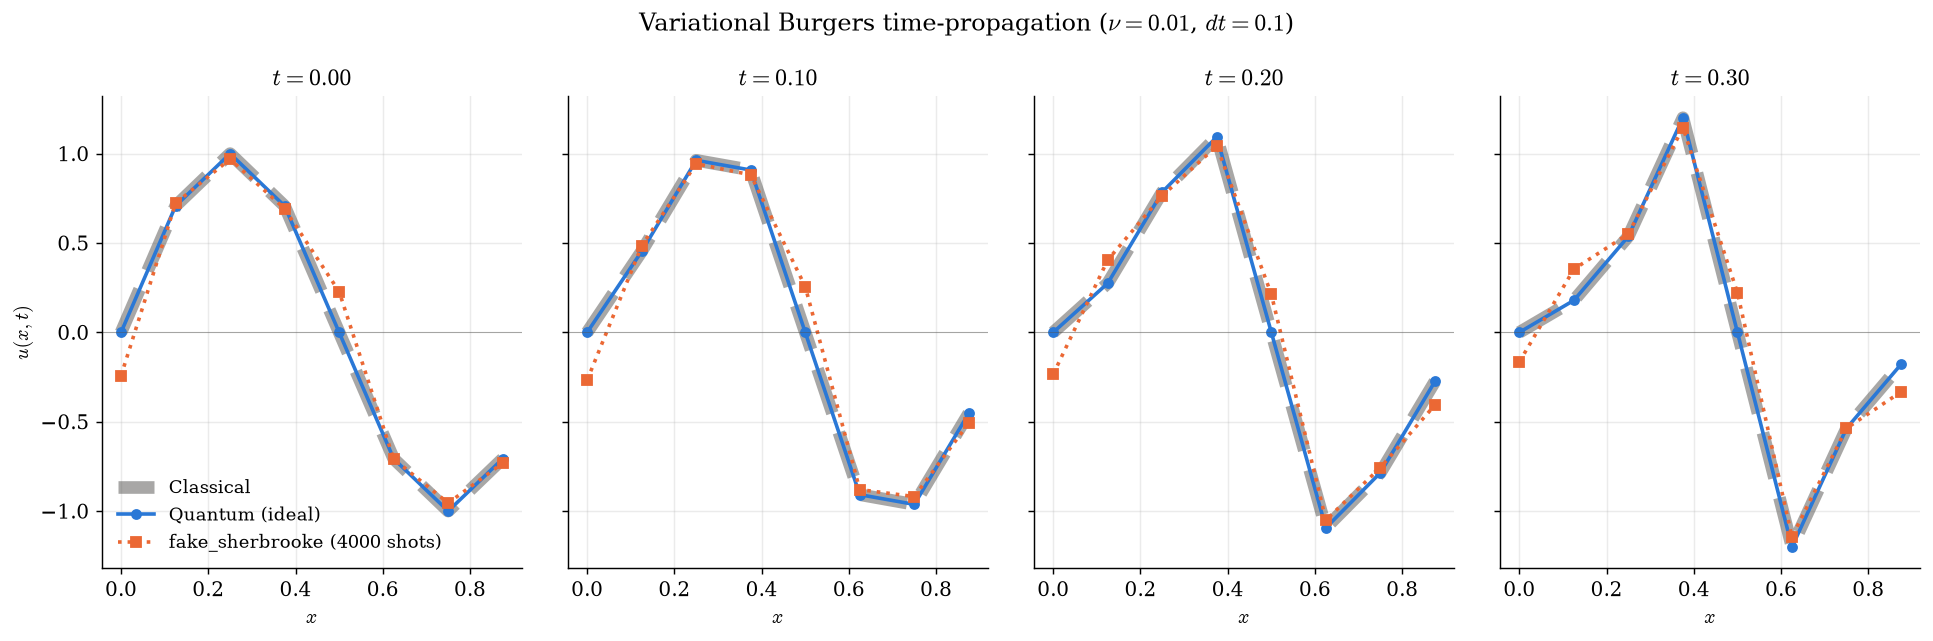

In [6]:
fig, axes = plt.subplots(1, n_steps + 1, figsize=(15, 5), sharey=True)
timesteps = np.arange(n_steps + 1) * dt
for i, ax in enumerate(axes):
    ax.plot(x, classical_states[i], "--", color=COLORS["classical"], lw=7, alpha=0.5, label="Classical")
    ax.plot(x, quantum_states[i], "-", color=COLORS["blue"], marker="o", label="Quantum (ideal)")
    ax.plot(x, fake_states[i], ":", color=COLORS["orange"], marker="s", label=f"{fake_backend.backend_name} ({SHOTS} shots)")
    ax.axhline(0, color=COLORS["classical"], lw=0.5, alpha=0.5)
    ax.set_title(f"$t = {timesteps[i]:.2f}$")
    ax.set_xlabel("$x$")
axes[0].set_ylabel("$u(x, t)$")
axes[0].legend(fontsize=10, loc="lower left")
fig.suptitle(f"Variational Burgers time-propagation ($\\nu={nu}$, $dt={dt}$)")
fig.tight_layout()

## Resource estimates

In [7]:
backend = FakeSherbrooke()


def circuit_stats(qc, opt=3):
    t = transpile(qc, backend=backend, optimization_level=opt, seed_transpiler=42)
    ops = t.count_ops()
    two_q = sum(v for k, v in ops.items() if k in ("ecr", "cx"))
    active = {t.find_bit(q).index for instr in t.data for q in instr.qubits}
    return {"qubits": len(active), "gates": sum(ops.values()), "two_qubit": two_q, "depth": t.depth()}


def print_stats(name, s):
    print(f"  {name}:")
    print(f"    qubits              : {s['qubits']}")
    print(f"    gate count          : {s['gates']}")
    print(f"    two-qubit gate count: {s['two_qubit']}")
    print(f"    depth               : {s['depth']}")


rng_r = np.random.default_rng(1)
theta_ref = rng_r.random(P) * 2 * np.pi
alpha = rng_r.random(P) * 2 * np.pi

qc_cross = QuantumCircuit(n)
qc_cross.append(ansatz.assign_parameters(theta_ref).to_gate(), range(n))
qc_cross.append(ansatz.assign_parameters(alpha).inverse().to_gate(), range(n))
print_stats("identity/linear cross-term circuit", circuit_stats(qc_cross))

qc_nl = pc.nonlinear_overlap_circuit(ansatz, theta_ref, alpha, shift_fwd)
print_stats("nonlinear cross-term circuit", circuit_stats(qc_nl))

qc_M = pc.metric_offdiag_circuit(ansatz, alpha, 0, 1)
print_stats("metric off-diagonal circuit", circuit_stats(qc_M))

  identity/linear cross-term circuit:
    qubits              : 3
    gate count          : 128
    two-qubit gate count: 12
    depth               : 68
  nonlinear cross-term circuit:
    qubits              : 6
    gate count          : 351
    two-qubit gate count: 44
    depth               : 148
  metric off-diagonal circuit:
    qubits              : 4
    gate count          : 85
    two-qubit gate count: 11
    depth               : 40
